In [1]:
!pip install wilds matplotlib torch torchvision terratorch


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from wilds import get_dataset
import pandas.core.tools.datetimes as _pd_dt_module
import matplotlib.pyplot as plt
import pandas as pd


my_root_path = "/mnt/windows/Users/kevin/Downloads/"

_true_orig_to_datetime = _pd_dt_module.to_datetime

def _patched_to_datetime(*args, **kwargs):
    # Always force ISO8601 — overrides missing OR incorrect format
    kwargs['format'] = 'ISO8601'
    return _true_orig_to_datetime(*args, **kwargs)

pd.to_datetime = _patched_to_datetime

#never use dataset, but use the metadata(it contains all IMAGES)
dataset = get_dataset(dataset="fmow", root_dir=my_root_path, download=False)

# Restore
pd.to_datetime = _true_orig_to_datetime

# Grab the pre-built, rich pandas DataFrame directly from the dataset
df = dataset.metadata.copy()

# Extract the timestamp safely by explicitly defining the ISO8601 format
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df['year_extracted'] = df['timestamp'].dt.year

#Find the exact column index for 'region' in the metadata_array
region_idx = dataset.metadata_fields.index('region')

# Retrieve the mapping list from the dataset (e.g., ['Asia', 'Europe', ...])
region_names_list = dataset.metadata_map['region']

df['region_names'] = df['region'].map(lambda x: region_names_list[int(x)])


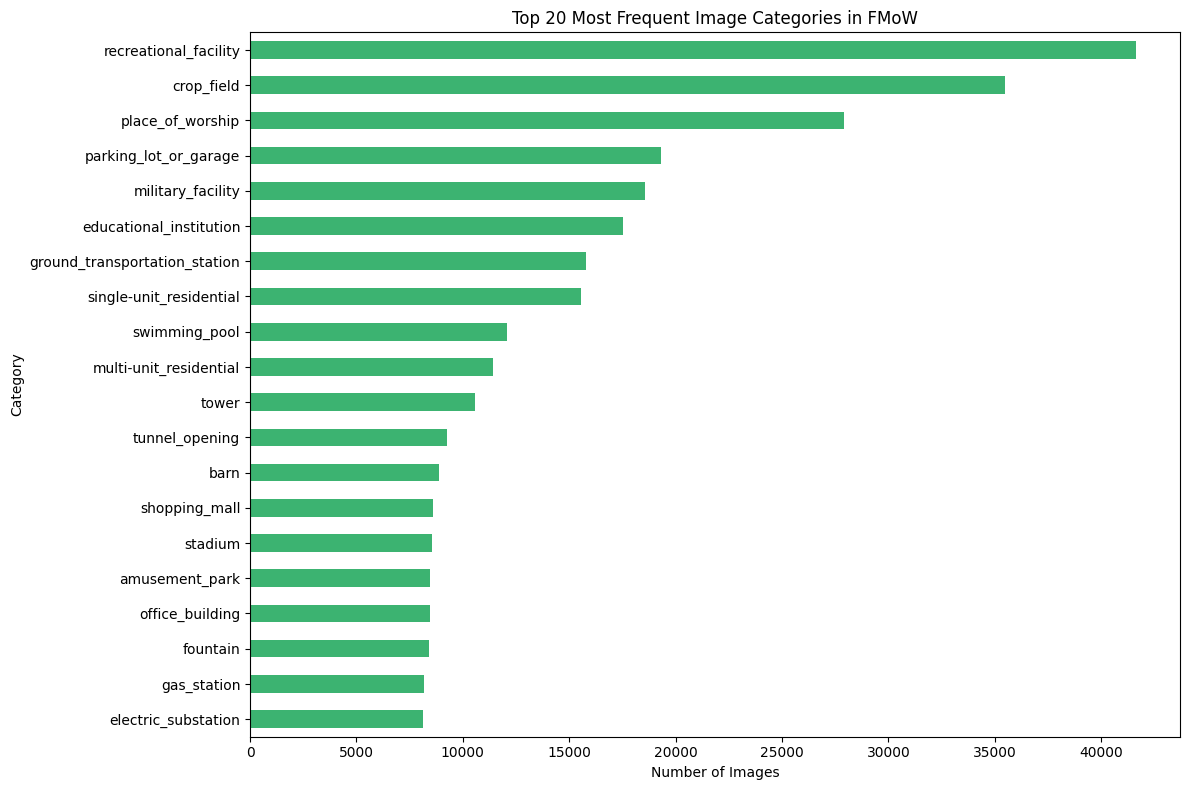

In [3]:
# ---------------------------------------------------------
# CHART 1: Top 20 Building / Land-Use Categories
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
top_categories = df['category'].value_counts().head(20)
top_categories.plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Most Frequent Image Categories in FMoW')
plt.xlabel('Number of Images')
plt.ylabel('Category')
plt.gca().invert_yaxis() # Put the largest bar at the top
plt.tight_layout()
plt.show()
plt.close('all')







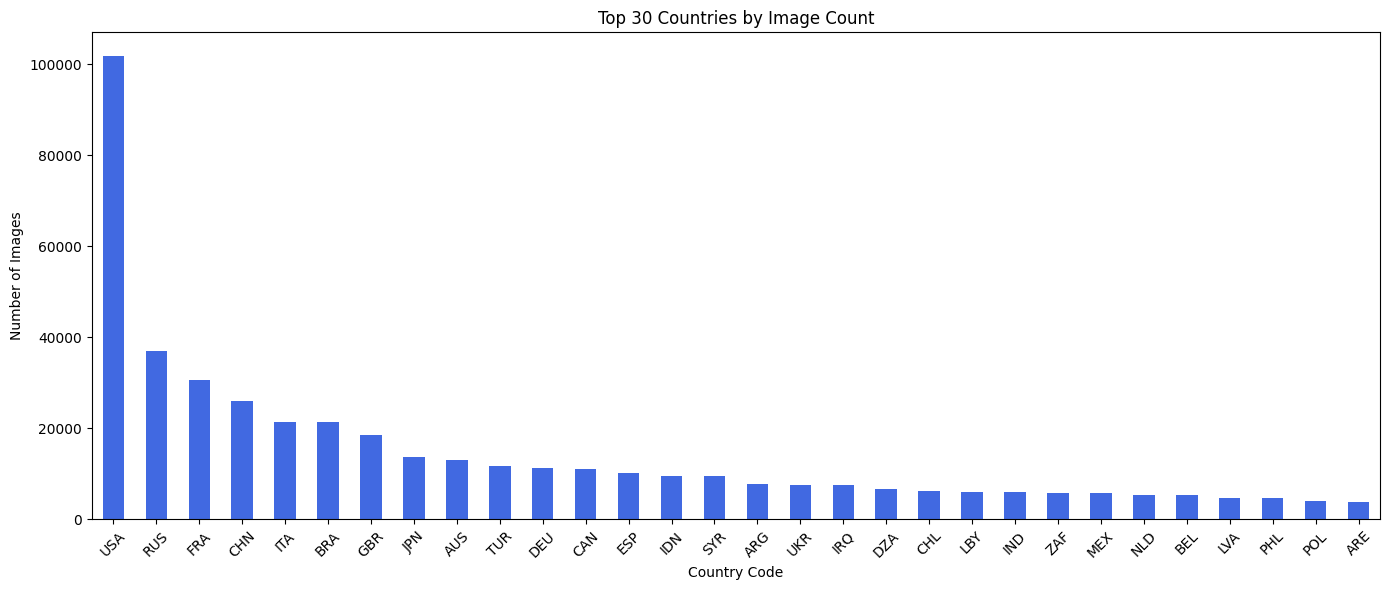

In [4]:
# ---------------------------------------------------------
# CHART 2: Image Distribution by Country Code
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
# Grabbing the top 30 country code
top_countries = df['country_code'].value_counts().head(30)
top_countries.plot(kind='bar', color='royalblue')
plt.title('Top 30 Countries by Image Count')
plt.xlabel('Country Code')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')

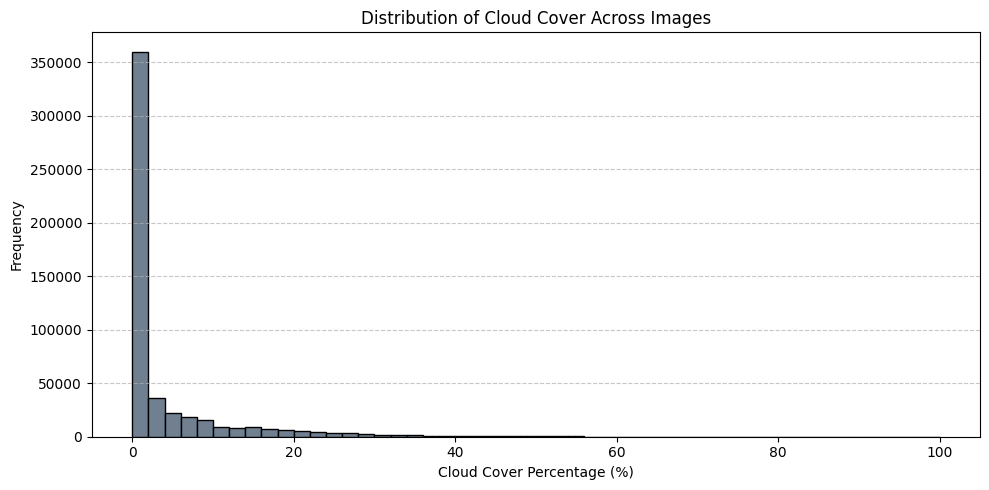

In [5]:
# ---------------------------------------------------------
# CHART 3: Cloud Cover Distribution
# ---------------------------------------------------------
# Satellite imagery often suffers from cloud obstruction.

plt.figure(figsize=(10, 5))
# Cloud cover is usually a percentage from 0 to 100
plt.hist(df['cloud_cover'], bins=50, color='slategray', edgecolor='black')
plt.title('Distribution of Cloud Cover Across Images')
plt.xlabel('Cloud Cover Percentage (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close('all')

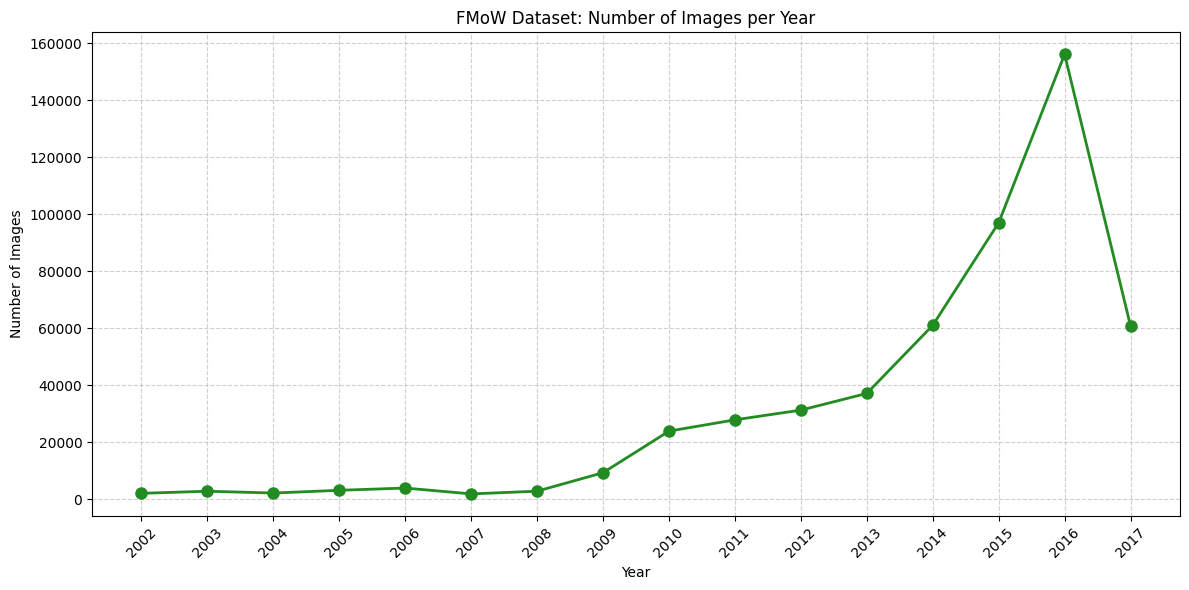

In [6]:
# ---------------------------------------------------------
# Chart 4: Year Distribution
# ---------------------------------------------------------
# Plot the distribution over time
plt.figure(figsize=(12, 6))
year_counts = df['year_extracted'].value_counts().sort_index()

year_counts.plot(kind='line', marker='o', color='forestgreen', linewidth=2, markersize=8)
plt.title('FMoW Dataset: Number of Images per Year')
plt.xlabel('Year')
plt.ylabel('Number of Images')
plt.grid(True, linestyle='--', alpha=0.6)

# Force the x-axis to display as clean integers
plt.xticks(year_counts.index, [int(y) for y in year_counts.index], rotation=45)

plt.tight_layout()
plt.show()
plt.close('all')

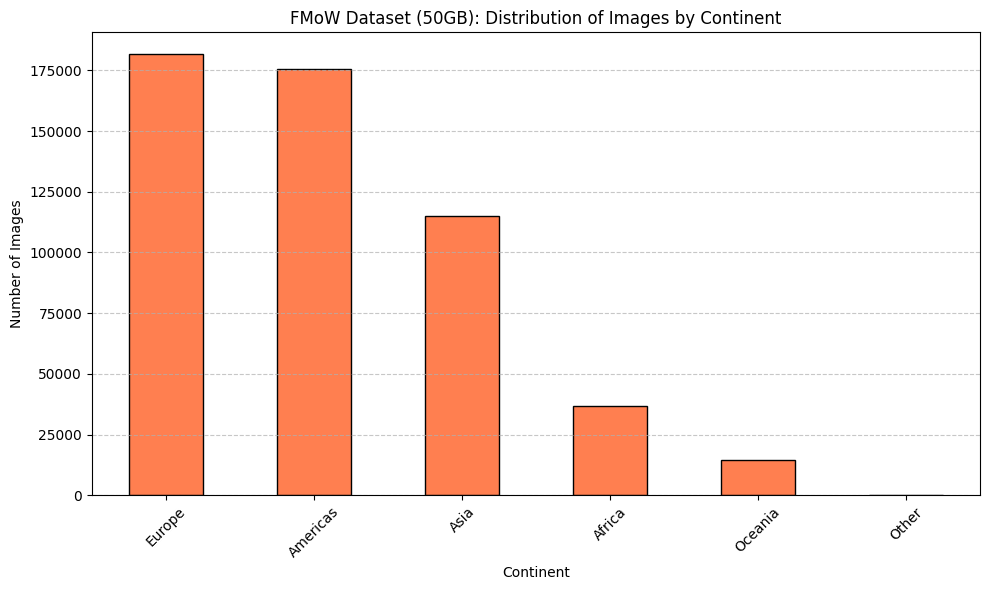

--- Images per Continent ---
region_names
Europe      181601
Americas    175597
Asia        115038
Africa       36722
Oceania      14616
Other          272


In [7]:
# ---------------------------------------------------------
# Chart 5: Continent / Region Distribution
# ---------------------------------------------------------

#Calculate counts and plot
plt.figure(figsize=(10, 6))
continent_counts = df['region_names'].value_counts()
continent_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('FMoW Dataset (50GB): Distribution of Images by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Images')

# Rotate the labels so they are easy to read
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("--- Images per Continent ---")
print(continent_counts.to_string())
plt.close('all')

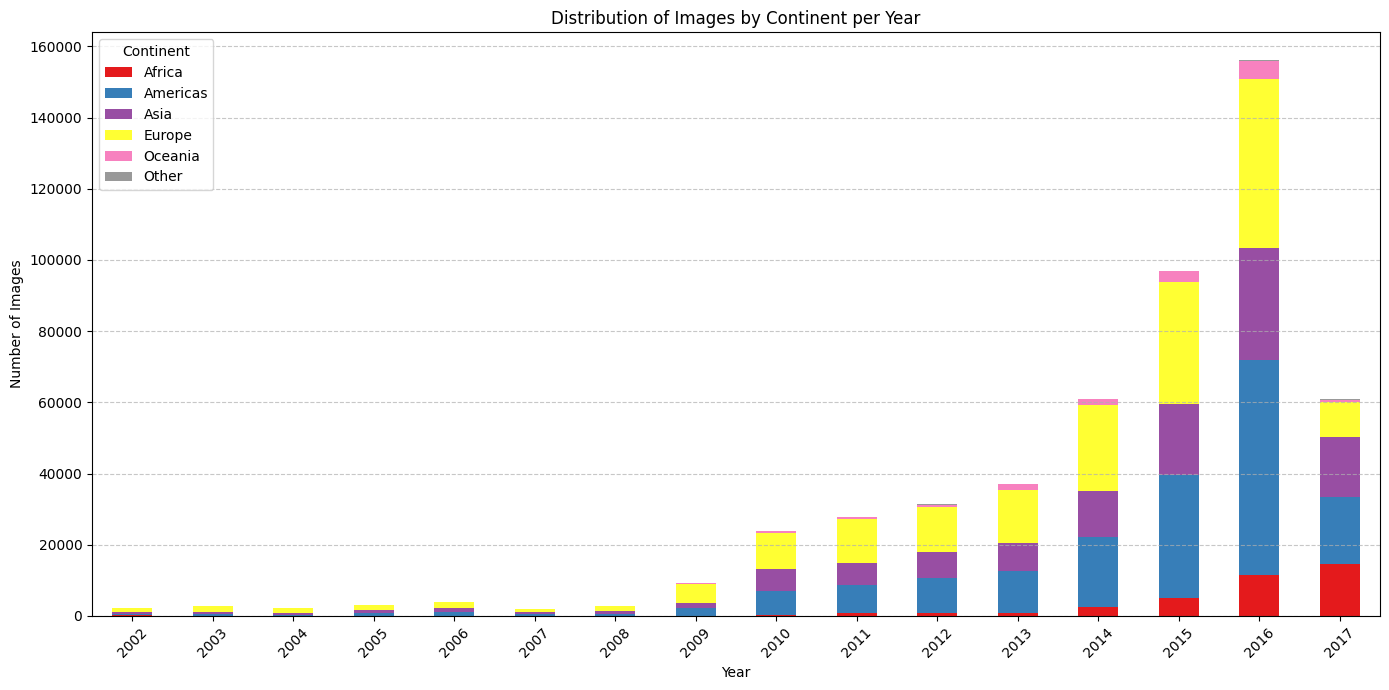

In [8]:
# ---------------------------------------------------------
# CHART 6: Distribution of images per year per continent
# ---------------------------------------------------------
#Group by Year and Region, count them, and 'unstack' to pivot the regions into columns
data_pivot = df.groupby(['year_extracted', 'region_names']).size().unstack(fill_value=0)
data_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set1')
plt.title('Distribution of Images by Continent per Year')
plt.xlabel('Year')
plt.ylabel('Number of Images')
plt.legend(title='Continent')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')

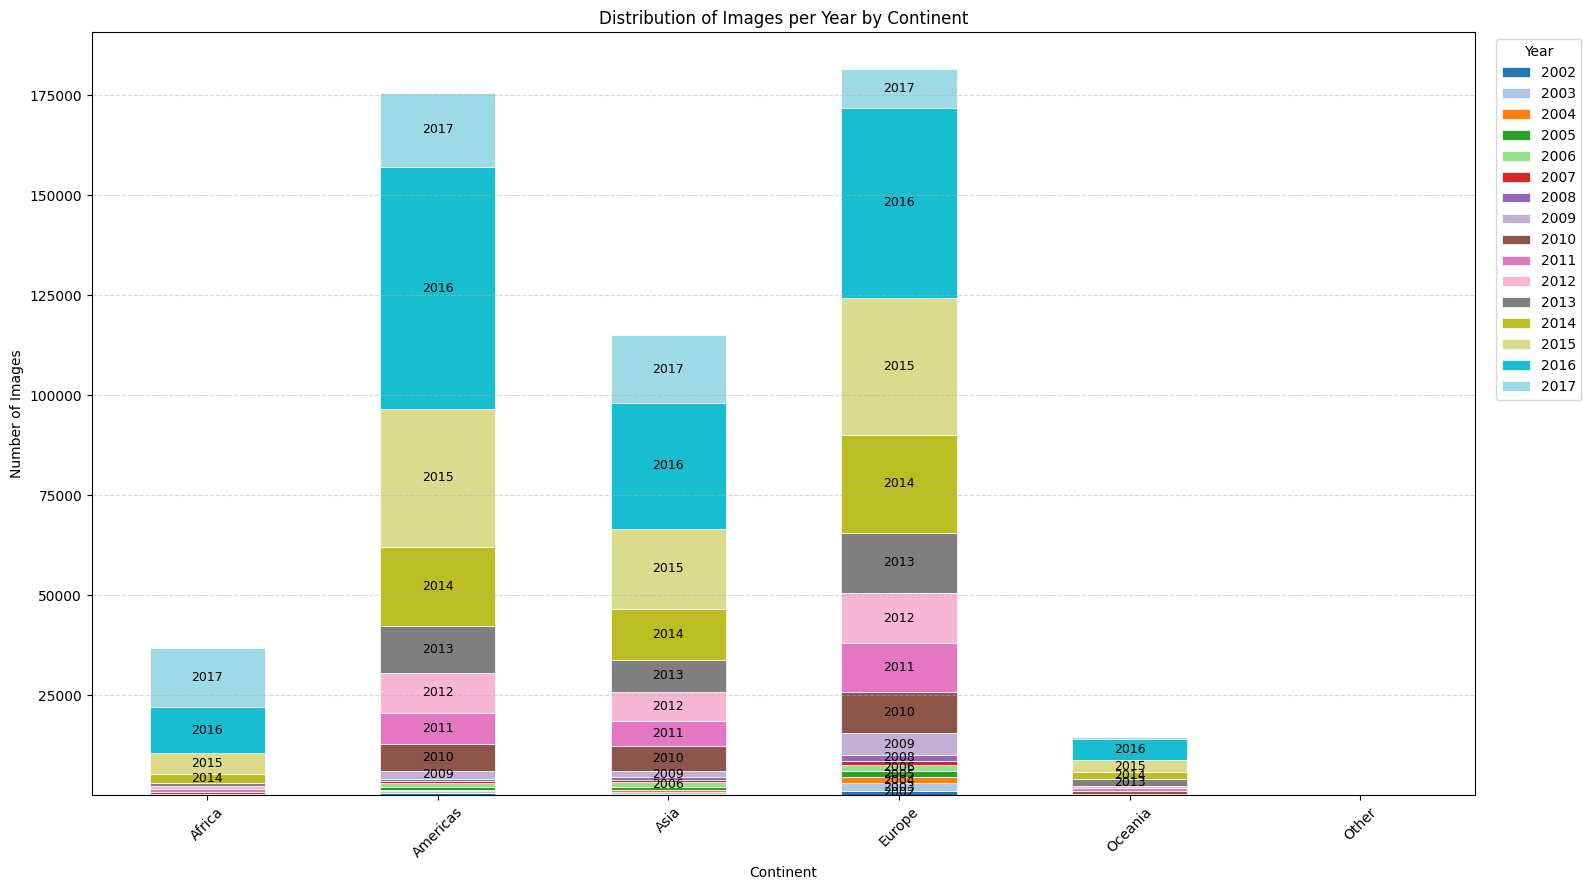

In [9]:
# ---------------------------------------------------------
# CHART 7: Distribution of images per continent per year
# ---------------------------------------------------------

#Group by Region and Year, count them, and 'unstack' to pivot the regions into columns
data_pivot = df.groupby(['region_names','year_extracted']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 9))
data_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Images per Year by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Images')

# Loop through the bar segments and add the year text inside!
# In a stacked bar chart, each container represents one column (one Year)
for container in ax.containers:
    # The label of the container is the actual year (e.g., 2011)
    year = container.get_label()

    # Create a list of labels for this specific year across all continents.
    # We only write the year if the bar segment represents more than 1000 images
    # to keep the chart clean and prevent text overlapping on tiny slivers.
    labels = [year if bar.get_height() > 1000 else "" for bar in container]
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


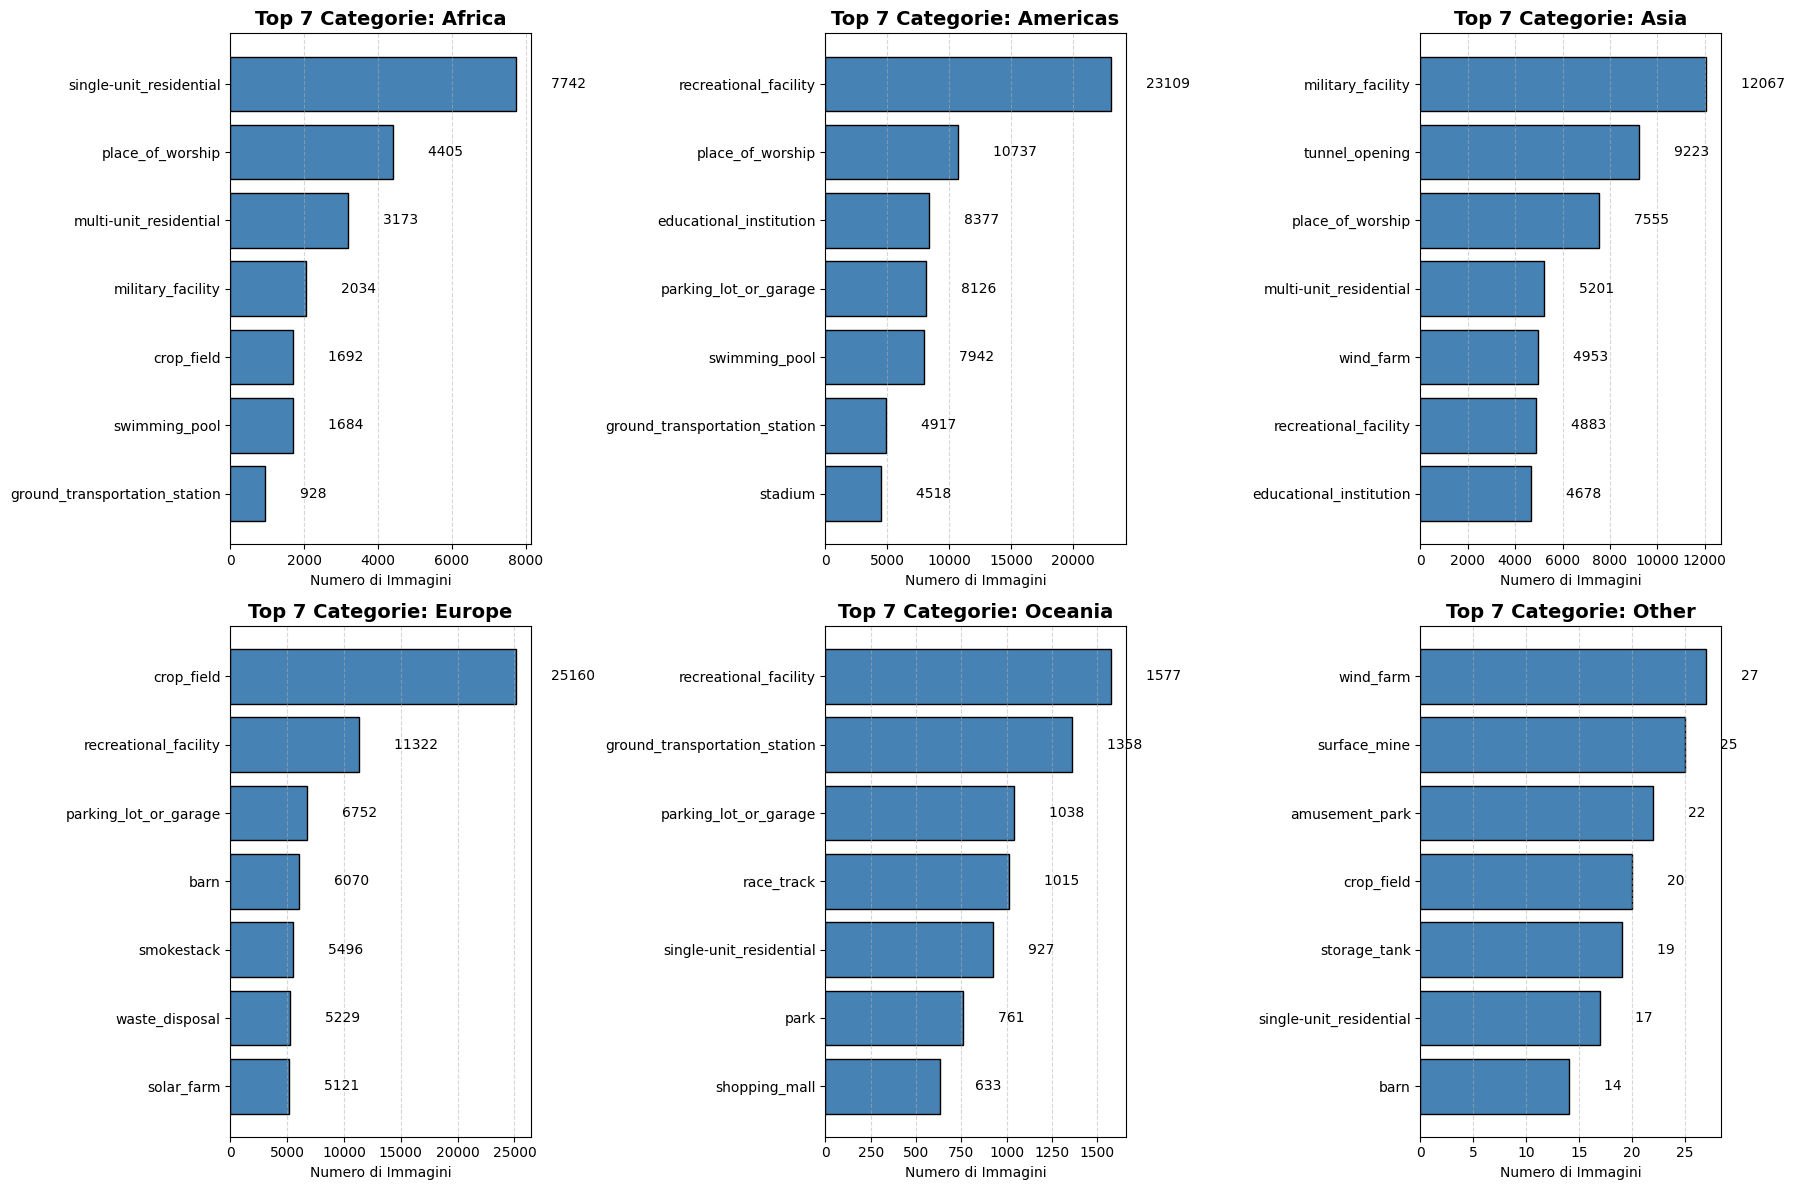

In [10]:
# ---------------------------------------------------------
# CHART 8: Distribution of top 5 label per continent
# ---------------------------------------------------------

counts = df.groupby(['region_names', 'category']).size().reset_index(name='count')
top_per_region = (counts.sort_values(['region_names', 'count'], ascending=[True, False])
                  .groupby('region_names')
                  .head(7))
continents = top_per_region['region_names'].unique()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, continent in enumerate(continents):
    ax = axes[i]
    subset = top_per_region[top_per_region['region_names'] == continent]
    subset = subset.sort_values('count', ascending=True)
    ax.barh(subset['category'], subset['count'], color='steelblue', edgecolor='black')
    for index, value in enumerate(subset['count']):
        ax.text(value, index, f'        {value}', va='center', fontsize=10)
    ax.set_title(f"Top 7 Categorie: {continent}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Numero di Immagini")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.close('all')

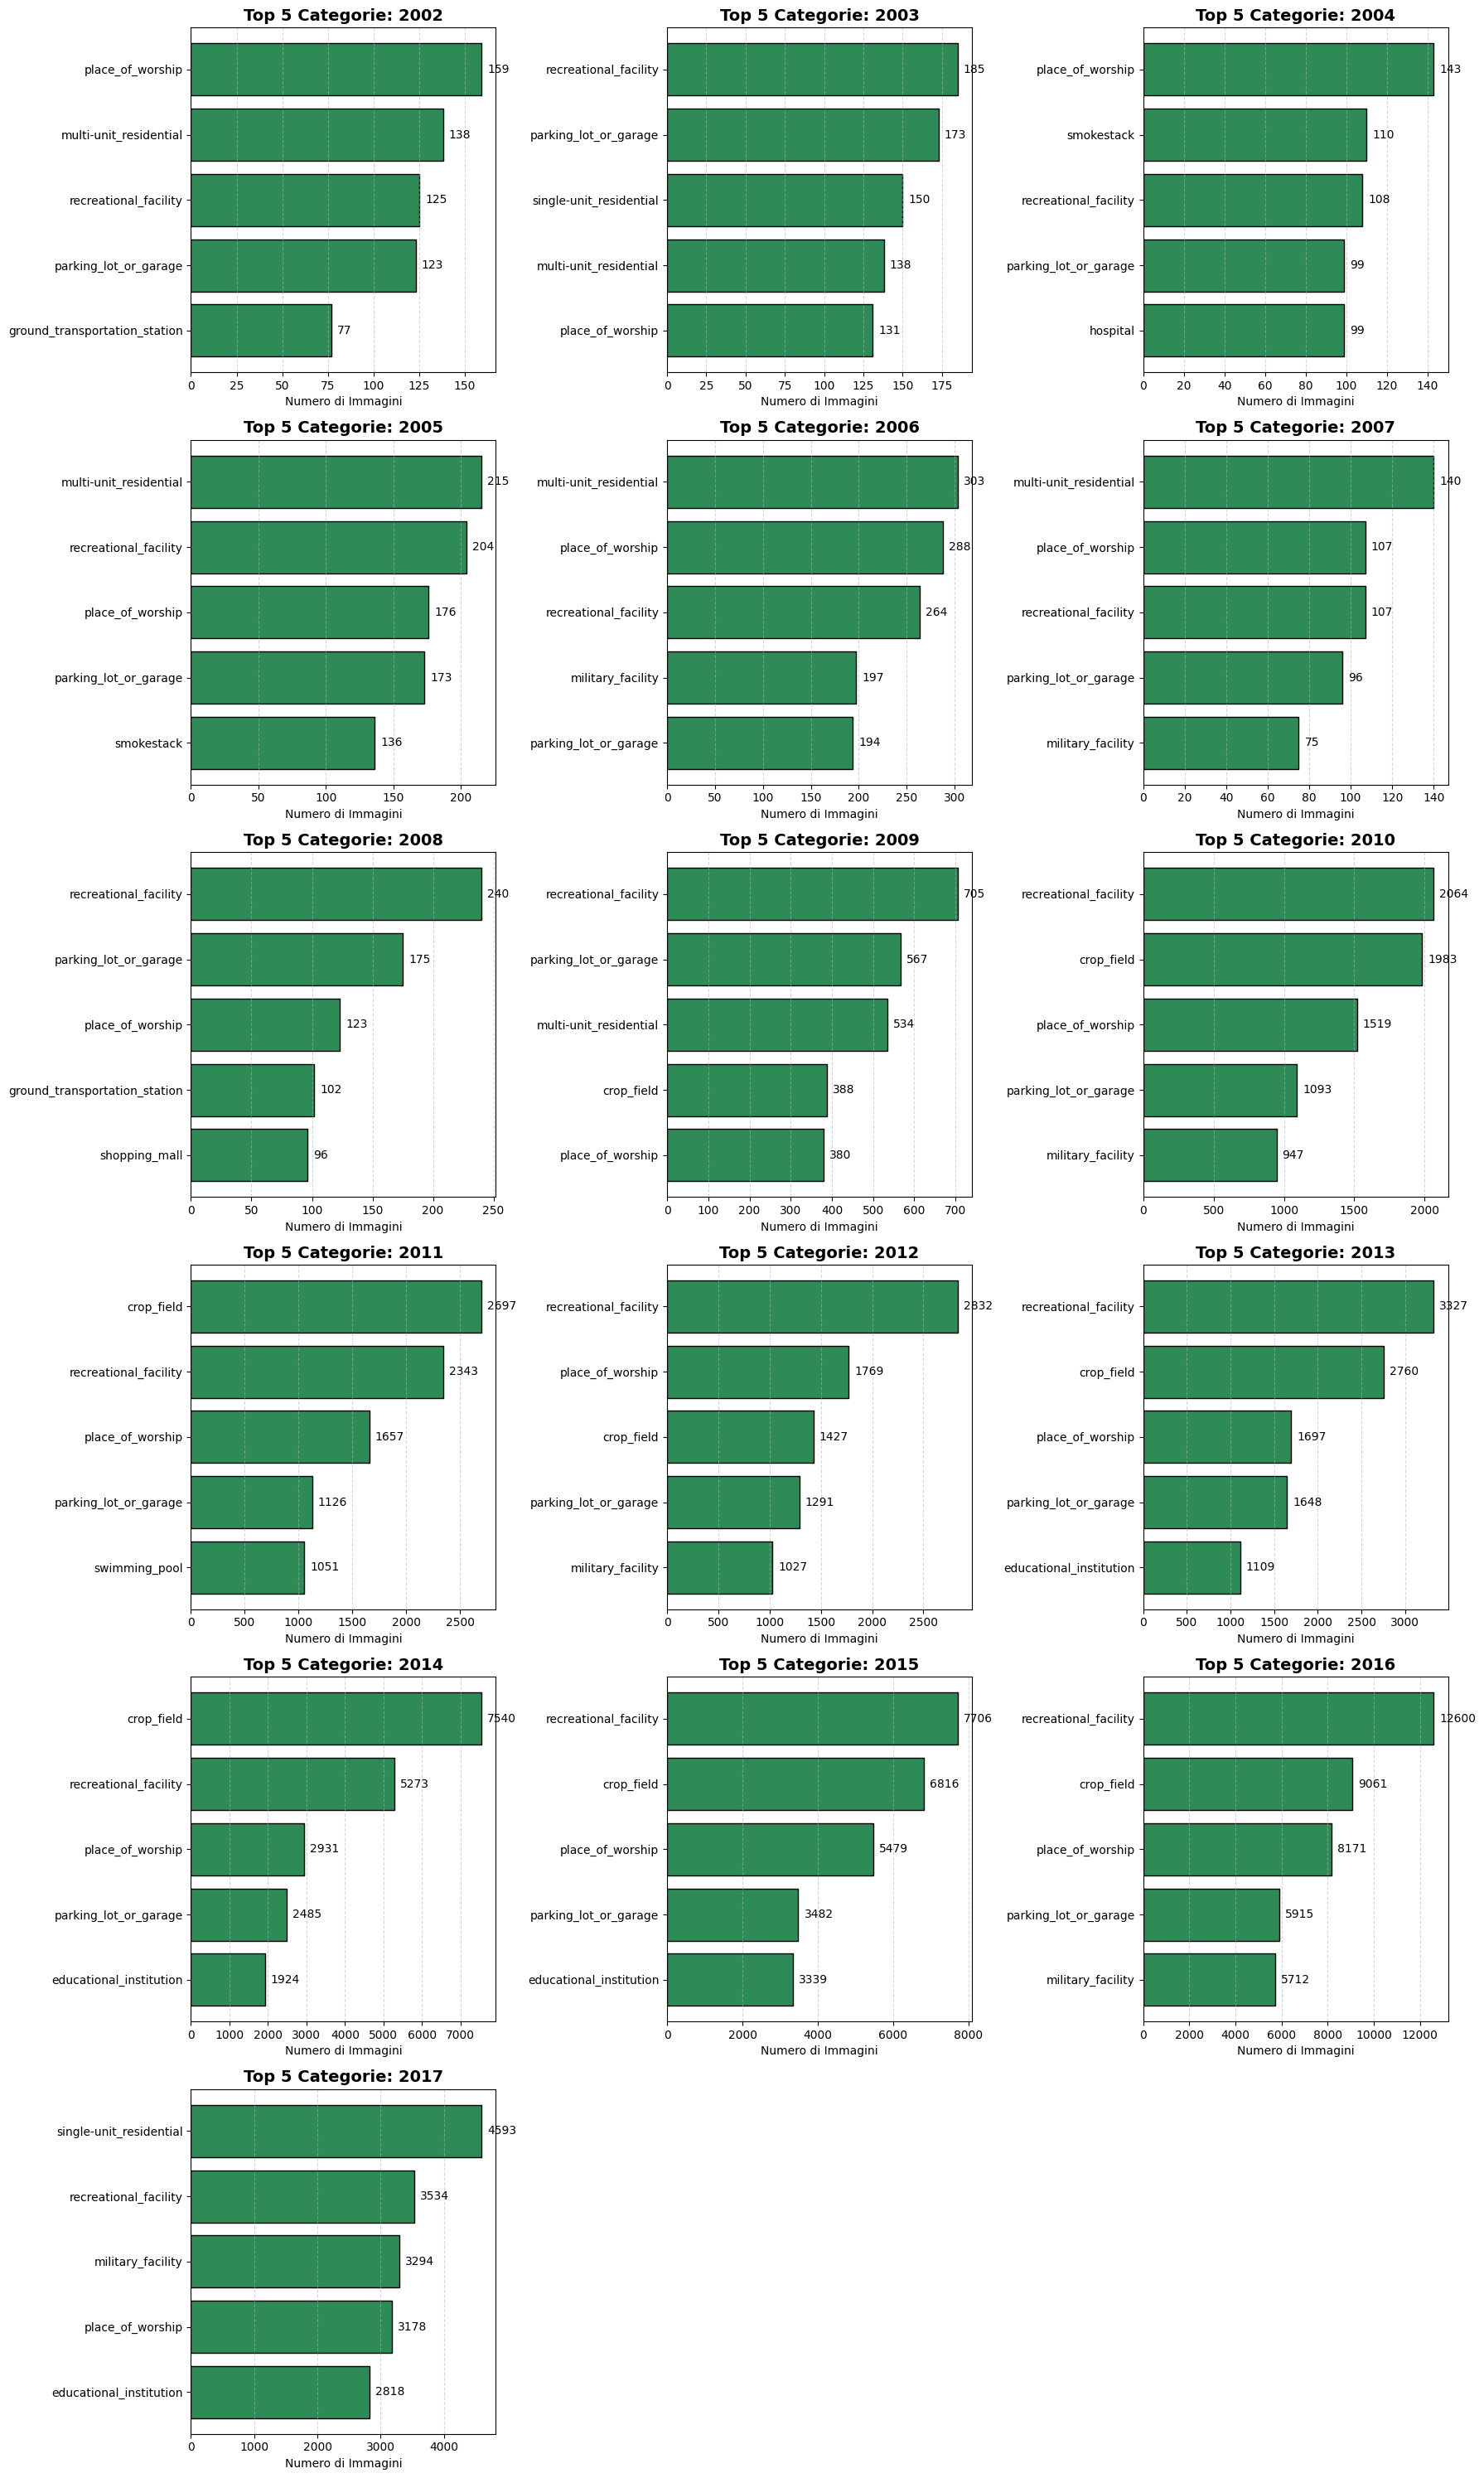

In [11]:
import math
# ---------------------------------------------------------
# CHART 9: Distribution of top 5 labels per continent per year
# ---------------------------------------------------------
counts = df.groupby(['year_extracted','category']).size().reset_index(name='count')
top_per_year = (counts.sort_values(['year_extracted', 'count'], ascending=[True, False])
                  .groupby('year_extracted')
                  .head(5))
years = top_per_year['year_extracted'].unique()
num_years = len(years)
ncols = 3
nrows = math.ceil(num_years / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()
for i, year in enumerate(years):
    ax = axes[i]
    subset = top_per_year[top_per_year['year_extracted'] == year]
    subset = subset.sort_values('count', ascending=True)
    ax.barh(subset['category'], subset['count'], color='seagreen', edgecolor='black')
    padding = subset['count'].max() * 0.02
    for index, value in enumerate(subset['count']):
        ax.text(value + padding, index, str(value), va='center', fontsize=10)
    ax.set_title(f"Top {5} Categorie: {int(year)}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Numero di Immagini")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.5)
for j in range(num_years, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.close('all')

--- Distribuzione Emisferi FMoW ---
Emisfero Nord (Lat > 0): 446,670 immagini (85.27%)
Emisfero Sud  (Lat < 0): 77,176 immagini (14.73%)


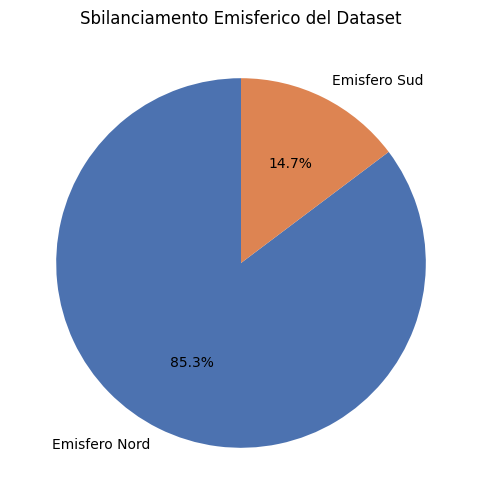

In [12]:
# ---------------------------------------------------------
# CHART 10: Distribution of images per latitude
# ---------------------------------------------------------
df_coords = df['lat']
nord = len(df_coords[df_coords > 0])
sud = len(df_coords[df_coords < 0])
totale = len(df_coords)
perc_nord = (nord / totale) * 100
perc_sud = (sud / totale) * 100
print("--- Distribuzione Emisferi FMoW ---")
print(f"Emisfero Nord (Lat > 0): {nord:,} immagini ({perc_nord:.2f}%)")
print(f"Emisfero Sud  (Lat < 0): {sud:,} immagini ({perc_sud:.2f}%)")
plt.figure(figsize=(6, 6))
plt.pie([nord, sud], labels=['Emisfero Nord', 'Emisfero Sud'],
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Sbilanciamento Emisferico del Dataset')
plt.show()
plt.close('all')

--- Distribuzione Emisferi FMoW ---
Emisfero Est (Lon > 0): 311,948 immagini (59.55%)
Emisfero Ovest  (Lon < 0): 211,898 immagini (40.45%)


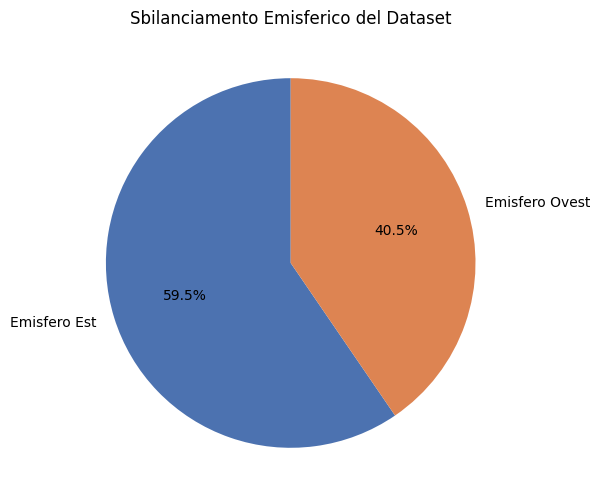

In [13]:
# ---------------------------------------------------------
# CHART 11: Distribution of images per longitude
# ---------------------------------------------------------

df_coords = df['lon']
est = len(df_coords[df_coords > 0])
ovest = len(df_coords[df_coords < 0])
totale = len(df_coords)
perc_est = (est / totale) * 100
perc_ovest = (ovest / totale) * 100

print("--- Distribuzione Emisferi FMoW ---")
print(f"Emisfero Est (Lon > 0): {est:,} immagini ({perc_est:.2f}%)")
print(f"Emisfero Ovest  (Lon < 0): {ovest:,} immagini ({perc_ovest:.2f}%)")

plt.figure(figsize=(6, 6))
plt.pie([est, ovest], labels=['Emisfero Est', 'Emisfero Ovest'],
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Sbilanciamento Emisferico del Dataset')
plt.show()
plt.close('all')

--- Distribuzione FMoW per Longitudine ---
Ovest (Americhe) [-180° a -30°]         : 175,831 immagini (33.57%)
Centro (Europa/Africa) [-30° a +60°]    : 250,156 immagini (47.75%)
Est (Asia/Oceania) [+60° a +180°]       : 97,859 immagini (18.68%)


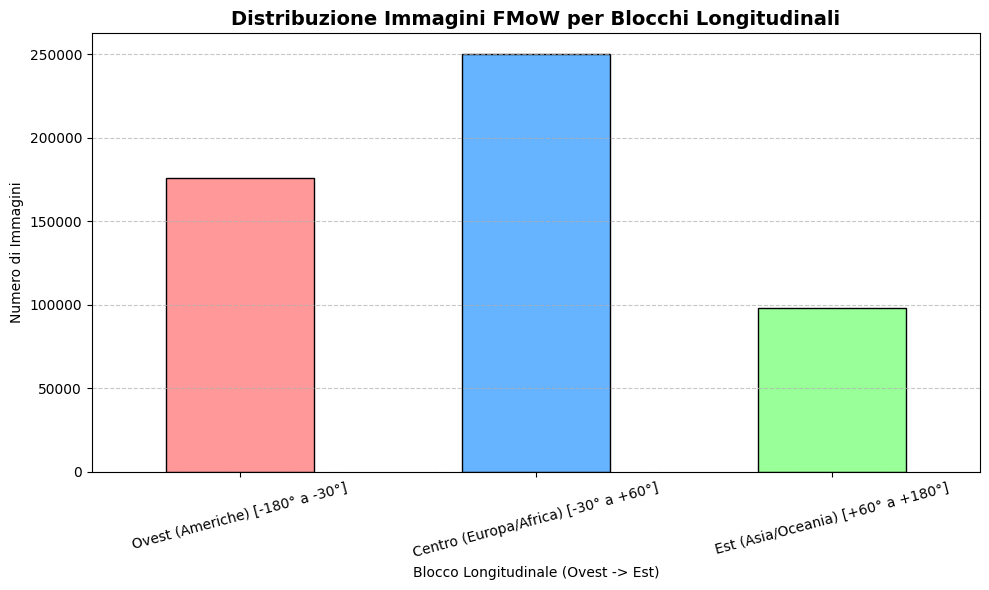

In [14]:
# ---------------------------------------------------------
# CHART 12: Distribution of Images for longitude ranges
# ---------------------------------------------------------
bins = [-180.0, -30.0, 60.0, 180.0]
labels = [
    'Ovest (Americhe) [-180° a -30°]',
    'Centro (Europa/Africa) [-30° a +60°]',
    'Est (Asia/Oceania) [+60° a +180°]'
]
data_pivot  = pd.cut(df['lon'], bins=bins, labels=labels, include_lowest=True)
zone_counts = data_pivot.value_counts().reindex(labels)
print("--- Distribuzione FMoW per Longitudine ---")
for index, value in zone_counts.items():
    perc = (value / len(df_coords)) * 100
    print(f"{index.ljust(40)}: {value:,} immagini ({perc:.2f}%)")
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']
zone_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribuzione Immagini FMoW per Blocchi Longitudinali', fontsize=14, fontweight='bold')
plt.xlabel('Blocco Longitudinale (Ovest -> Est)')
plt.ylabel('Numero di Immagini')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close('all')

--- Distribuzione FMoW per Fasce Latitudinali ---
Zona Polare Sud (<-66.5°)               : 0 immagini (0.00%)
Zona Temperata Sud (-66.5° a -23.5°)    : 40,246 immagini (7.68%)
Fascia Tropicale (-23.5° a +23.5°)      : 83,988 immagini (16.03%)
Zona Temperata Nord (+23.5° a +66.5°)   : 398,712 immagini (76.11%)
Zona Polare Nord (>+66.5°)              : 900 immagini (0.17%)


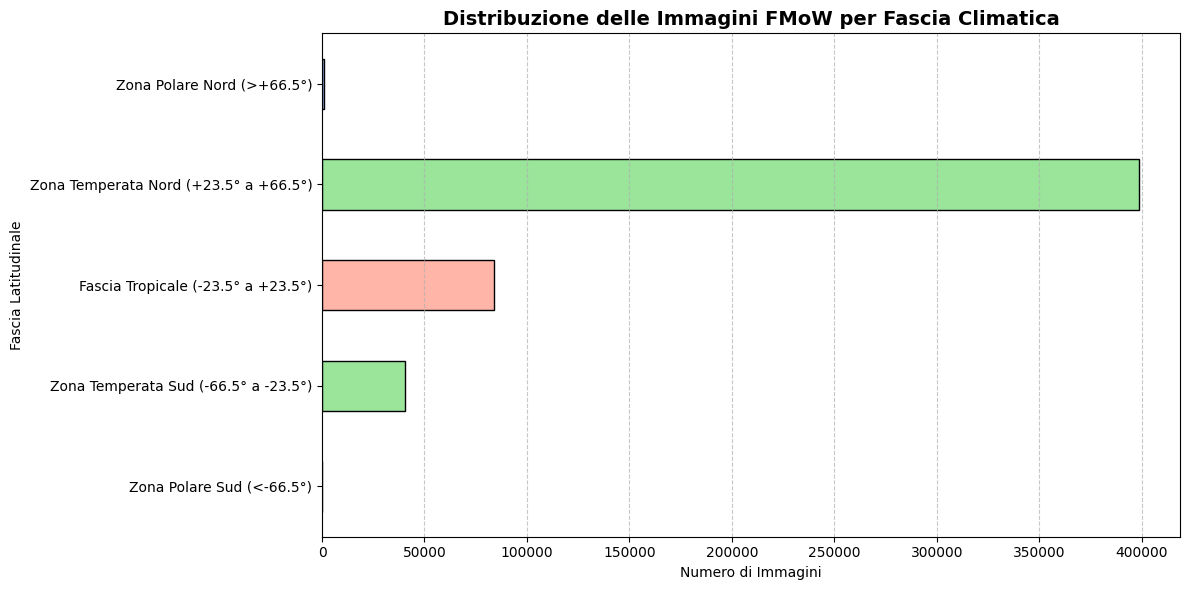

In [15]:
# ---------------------------------------------------------
# CHART 7: Distribution of images per latitude ranges
# ---------------------------------------------------------
bins = [-90.0, -66.5, -23.5, 23.5, 66.5, 90.0]
labels = [
    'Zona Polare Sud (<-66.5°)',
    'Zona Temperata Sud (-66.5° a -23.5°)',
    'Fascia Tropicale (-23.5° a +23.5°)',
    'Zona Temperata Nord (+23.5° a +66.5°)',
    'Zona Polare Nord (>+66.5°)'
]
data_pivot = pd.cut(df['lat'], bins=bins, labels=labels, include_lowest=True)
zone_counts =data_pivot.value_counts().reindex(labels)
print("--- Distribuzione FMoW per Fasce Latitudinali ---")
for index, value in zone_counts.items():
    perc = (value / len(df_coords)) * 100
    print(f"{index.ljust(40)}: {value:,} immagini ({perc:.2f}%)")

plt.figure(figsize=(12, 6))
colors = ['#a0c4ff', '#9ae59a', '#ffb5a7', '#9ae59a', '#a0c4ff']
zone_counts.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Distribuzione delle Immagini FMoW per Fascia Climatica', fontsize=14, fontweight='bold')
plt.xlabel('Numero di Immagini')
plt.ylabel('Fascia Latitudinale')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close('all')

In [16]:
# ---------------------------------------------------------
# CHART 14: Labels missing for each year
# ---------------------------------------------------------

cross_matrix = pd.crosstab(index=df['year_extracted'], columns=df['category'])
classi_mancanti_per_anno = {}
for year in cross_matrix.index:
    year_data = cross_matrix.loc[year]
    mancanti = year_data[year_data == 0].index.tolist()
    classi_mancanti_per_anno[year] = mancanti
print("--- REPORT CLASSI MANCANTI PER ANNO ---")
for year, mancanti in classi_mancanti_per_anno.items():
    print(f"\nAnno {int(year)} | Classi mancanti: {len(mancanti)}")
    if len(mancanti) > 0:
        print(f" -> {', '.join(mancanti)}")
    else:
        print(" -> Tutte le classi sono presenti!")

--- REPORT CLASSI MANCANTI PER ANNO ---

Anno 2002 | Classi mancanti: 5
 -> aquaculture, car_dealership, flooded_road, oil_or_gas_facility, space_facility

Anno 2003 | Classi mancanti: 2
 -> car_dealership, flooded_road

Anno 2004 | Classi mancanti: 3
 -> car_dealership, flooded_road, nuclear_powerplant

Anno 2005 | Classi mancanti: 4
 -> aquaculture, car_dealership, flooded_road, impoverished_settlement

Anno 2006 | Classi mancanti: 3
 -> aquaculture, car_dealership, flooded_road

Anno 2007 | Classi mancanti: 4
 -> car_dealership, flooded_road, lake_or_pond, space_facility

Anno 2008 | Classi mancanti: 4
 -> car_dealership, impoverished_settlement, nuclear_powerplant, space_facility

Anno 2009 | Classi mancanti: 1
 -> space_facility

Anno 2010 | Classi mancanti: 0
 -> Tutte le classi sono presenti!

Anno 2011 | Classi mancanti: 0
 -> Tutte le classi sono presenti!

Anno 2012 | Classi mancanti: 0
 -> Tutte le classi sono presenti!

Anno 2013 | Classi mancanti: 0
 -> Tutte le classi son

In [17]:
# ---------------------------------------------------------
# CHART 15: Number of labels missing per continent per year
# ---------------------------------------------------------
cross_matrix = pd.crosstab(
    index=[df['year_extracted'], df['region_names']],
    columns=df['category']
)
classi_mancanti_per_anno = {}

for year, region in cross_matrix.index:
    row_data = cross_matrix.loc[(year, region)]
    mancanti = row_data[row_data == 0].index.tolist()
    classi_mancanti_per_anno[(year,region)] = mancanti

print("--- REPORT CLASSI MANCANTI PER ANNO E CONTINENTE ---")
for year, region in sorted(classi_mancanti_per_anno.keys()):
    print(f"\n================ ANNO {year} ================")
    mancanti = classi_mancanti_per_anno[(year,region)]
    print(f"[{region}] | Classi mancanti: {len(mancanti)} su {len(cross_matrix.columns)}")
    if len(mancanti) > 0:
        print(f" -> {', '.join(mancanti[:5])}" + ("..." if len(mancanti) > 5 else ""))
    else:
        print(" -> Tutte le classi sono presenti!")



--- REPORT CLASSI MANCANTI PER ANNO E CONTINENTE ---

================ ANNO 2002 ================
[Africa] | Classi mancanti: 39 su 62
 -> airport, airport_hangar, airport_terminal, aquaculture, archaeological_site...

================ ANNO 2002 ================
[Americas] | Classi mancanti: 18 su 62
 -> airport, aquaculture, border_checkpoint, car_dealership, debris_or_rubble...

================ ANNO 2002 ================
[Asia] | Classi mancanti: 20 su 62
 -> aquaculture, barn, border_checkpoint, car_dealership, debris_or_rubble...

================ ANNO 2002 ================
[Europe] | Classi mancanti: 8 su 62
 -> aquaculture, car_dealership, flooded_road, impoverished_settlement, oil_or_gas_facility...

================ ANNO 2002 ================
[Oceania] | Classi mancanti: 61 su 62
 -> airport, airport_hangar, airport_terminal, amusement_park, aquaculture...

================ ANNO 2003 ================
[Africa] | Classi mancanti: 47 su 62
 -> airport, airport_hangar, airport_ter

In [18]:
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------

from pathlib import Path
from PIL import Image
import torchvision.transforms as T
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
transform = T.Compose([
    T.ToTensor(),         # Converts PIL Image to tensor and scales to [0.0, 1.0]
    T.Normalize(mean=MEAN, std=STD) # Shifts distribution to mean 0, std 1
])
def get_input(idx):
        """
        Returns x for a given idx.
        """
        img = Image.open(Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png').convert('RGB')
        return img


def get_tensor_images(numberOfImages):
    # Standard ImageNet statistics (commonly used for RGB satellite imagery too)
    lista_tensori = []
    for i in range(0,numberOfImages):
        img = get_input(i)
        img_t = transform(img)
        lista_tensori.append(img_t)

    batch_immagini = torch.stack(lista_tensori,dim = 0)
    return batch_immagini



In [19]:
# --- INFERENCE FM LOOP ---
""""
import gc

# Highly recommended to install tqdm (!pip install tqdm) for a progress bar
from tqdm import tqdm

total_images = 128
batch_size = 32

# 1. Setup Device and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# (Optional) A list to store results if you need to save them later
all_features = []

with torch.no_grad():
    # tqdm provides a progress bar calculating ETA automatically
    for offset in tqdm(range(0, total_images, batch_size), desc="Processing FMoW"):

        # 2. Prevent crashing on the very last batch
        # If there are fewer than 64 images left, it only loads what remains
        current_batch_size = min(batch_size, total_images - offset)

        batch = []
        for i in range(current_batch_size):
            img = get_input(offset + i)
            img = transform(img) # Overwrite to save memory immediately
            batch.append(img)

        # 3. Stack and move directly to GPU
        input_tensor = torch.stack(batch, dim=0).to(device)
        del batch # Free system RAM immediately

        # 4. Forward Pass
        output = model(input_tensor)[-1]

        # 5. Handle Output Safely
        # Move output back to CPU so it doesn't hoard valuable VRAM
        all_features.append(output)

        # 6. Aggressive Memory Cleanup
        del input_tensor
        del output

        # Every ~100 batches, force the Python garbage collector to clean system RAM
        if (offset // batch_size) % 100 == 0:
            gc.collect()
"""

'"\nimport gc\n\n# Highly recommended to install tqdm (!pip install tqdm) for a progress bar\nfrom tqdm import tqdm\n\ntotal_images = 128\nbatch_size = 32\n\n# 1. Setup Device and Model\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nmodel = model.to(device)\nmodel.eval()\n\n# (Optional) A list to store results if you need to save them later\nall_features = []\n\nwith torch.no_grad():\n    # tqdm provides a progress bar calculating ETA automatically\n    for offset in tqdm(range(0, total_images, batch_size), desc="Processing FMoW"):\n\n        # 2. Prevent crashing on the very last batch\n        # If there are fewer than 64 images left, it only loads what remains\n        current_batch_size = min(batch_size, total_images - offset)\n\n        batch = []\n        for i in range(current_batch_size):\n            img = get_input(offset + i)\n            img = transform(img) # Overwrite to save memory immediately\n            batch.append(img)\n\n        # 3. Stack 

In [20]:
from torch import nn
import EmaTeacher
import FeatureDistillation
import FoundationModel
import Student
import torch


#algorithm

# ---------------------------------------------------------
# PIPELINE DI INGRESSO DATI
# ---------------------------------------------------------
#STEP 1: LOADING DATASET
#STEP 2: ORDERING DATASET TO CREATE CONCEPTS based on continent...
#STEP 3: EACH CONCEPT CAN BE SHUFFLED OR ORDER BY TIME OR CICLIC CONCEPTS
#STEP 4: [SETUP DATALOADER]


# ---------------------------------------------------------
# TRAINING E MODELLI
# ---------------------------------------------------------
#STEP 5: LOAD FOUNDATION MODEL AND STUDENT(ResNet18) [AND EMA TEACHER]
student = Student.Student(numberOfClasses=62)
ema_teacher = EmaTeacher.EmaTeacher(student, alpha=0.9) # alpha usually high, e.g., 0.9 or 0.99
FM = FoundationModel.FoundationModel()

# Setup Distiller (Assuming FM outputs 768 dim(non è giusto occhio), Student ResNet18 outputs 512 dim)
distiller = FeatureDistillation.LinearReluDistiller(dimFeatureStudent=512, dimFeatureTeacher=768)

optimizer = torch.optim.Adam(list(student.parameters()) + list(distiller.parameters()), lr=1e-4)
ce_loss_fn = nn.CrossEntropyLoss()

batch_size = 32
lambda_dist = 0.5 # Hyperparameter for Total Loss weighting

#STEP 6: TRAINING in STREAM: PREQUENTIAL EVALUTATION OR interleaved TEST-then-TRAIN
buffer_imgs = []
buffer_labels = []

print("Starting Streaming Pipeline...")

for step in range(100):
    img, label = torch.randn(1, 3, 224, 224), torch.tensor([0])

    # 1. PREQUENTIAL EVALUATION: Predict with EMA Teacher first
    prediction_logits = ema_teacher.predict(img)
    predicted_class = torch.argmax(prediction_logits, dim=1)
    # Store metric (e.g., accuracy = (predicted_class == label).item())

    # 2. Add to buffer
    buffer_imgs.append(img)
    buffer_labels.append(label)

    # 3. Train when buffer reaches size
    if len(buffer_imgs) == batch_size:
        batch_imgs = torch.cat(buffer_imgs, dim=0)
        batch_labels = torch.cat(buffer_labels, dim=0)

        optimizer.zero_grad()

        # Forward Student
        student_output = student(batch_imgs)
        logits = student_output['logits']
        student_features = student_output['features']

        # Calculate CE Loss (L_CE)
        loss_ce = ce_loss_fn(logits, batch_labels)

        # Calculate Distillation Loss (L_Dist) if FM is active
        fm_active = True # You can implement p_send logic here later
        loss_dist = 0.0
        if fm_active:
            teacher_features = FM(batch_imgs)
            loss_dist = distiller(student_features, teacher_features)

        # Total Loss -> L_tot = L_CE + λ L_Dist
        loss_tot = loss_ce + lambda_dist * loss_dist

        # Update Student + Projector
        loss_tot.backward()
        optimizer.step()

        # Update EMA Teacher
        ema_teacher.update(student)

        # Clear buffer
        buffer_imgs.clear()
        buffer_labels.clear()

    print("Streaming cycle completed.")

#STEP 7: PLOTTING PERFOMANCE METRIC




/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in /home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Starting Streaming Pipeline...
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle completed.
Streaming cycle complete